In [10]:
# ===== CELL 1 : Imports =====

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.manifold import Isomap
from sklearn.feature_selection import SelectPercentile
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib import offsetbox
import re
import os
from PIL import Image
%matplotlib inline

In [11]:
# ===== CELL 2 : Chargement du CSV =====

df = pd.read_csv("./df_plant_new2.csv")

# Data Exploration

In [12]:
# ===== CELL 4 : Info DataFrame =====

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   label_all      8 non-null      object
 1   label_plant    8 non-null      object
 2   label_disease  8 non-null      object
 3   filename       8 non-null      object
 4   filepath       8 non-null      object
dtypes: object(5)
memory usage: 452.0+ bytes


In [13]:
# ===== CELL 5 : Aperçu des données =====

df.head(10)

,label_all,label_plant,label_disease,filename,filepath
0,Apple___Apple_scab,Apple,Apple_scab,0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Sc...,../data/PlantVSDiseasesDataset/train/Apple___A...
1,Apple___Apple_scab,Apple,Apple_scab,0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Sc...,../data/PlantVSDiseasesDataset/train/Apple___A...
2,Apple___Apple_scab,Apple,Apple_scab,0a769a71-052a-4f19-a4d8-b0f0cb75541c___FREC_Sc...,../data/PlantVSDiseasesDataset/train/Apple___A...
3,Apple___healthy,Apple,healthy,00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7...,../data/PlantVSDiseasesDataset/train/Apple___h...
4,Apple___healthy,Apple,healthy,00fca0da-2db3-481b-b98a-9b67bb7b105c___RS_HL 7...,../data/PlantVSDiseasesDataset/train/Apple___h...
5,Apple___healthy,Apple,healthy,0a285c8b-1c31-48d4-89f2-af8b9edc36f6___RS_HL 5...,../data/PlantVSDiseasesDataset/train/Apple___h...
6,Apple___healthy,Apple,healthy,0a553fc0-fc2c-4598-baba-3bc10191447c___RS_HL 5...,../data/PlantVSDiseasesDataset/train/Apple___h...
7,Apple___healthy,Apple,healthy,0adc1c5b-8958-47c0-a152-f28078c214f1___RS_HL 7...,../data/PlantVSDiseasesDataset/train/Apple___h...


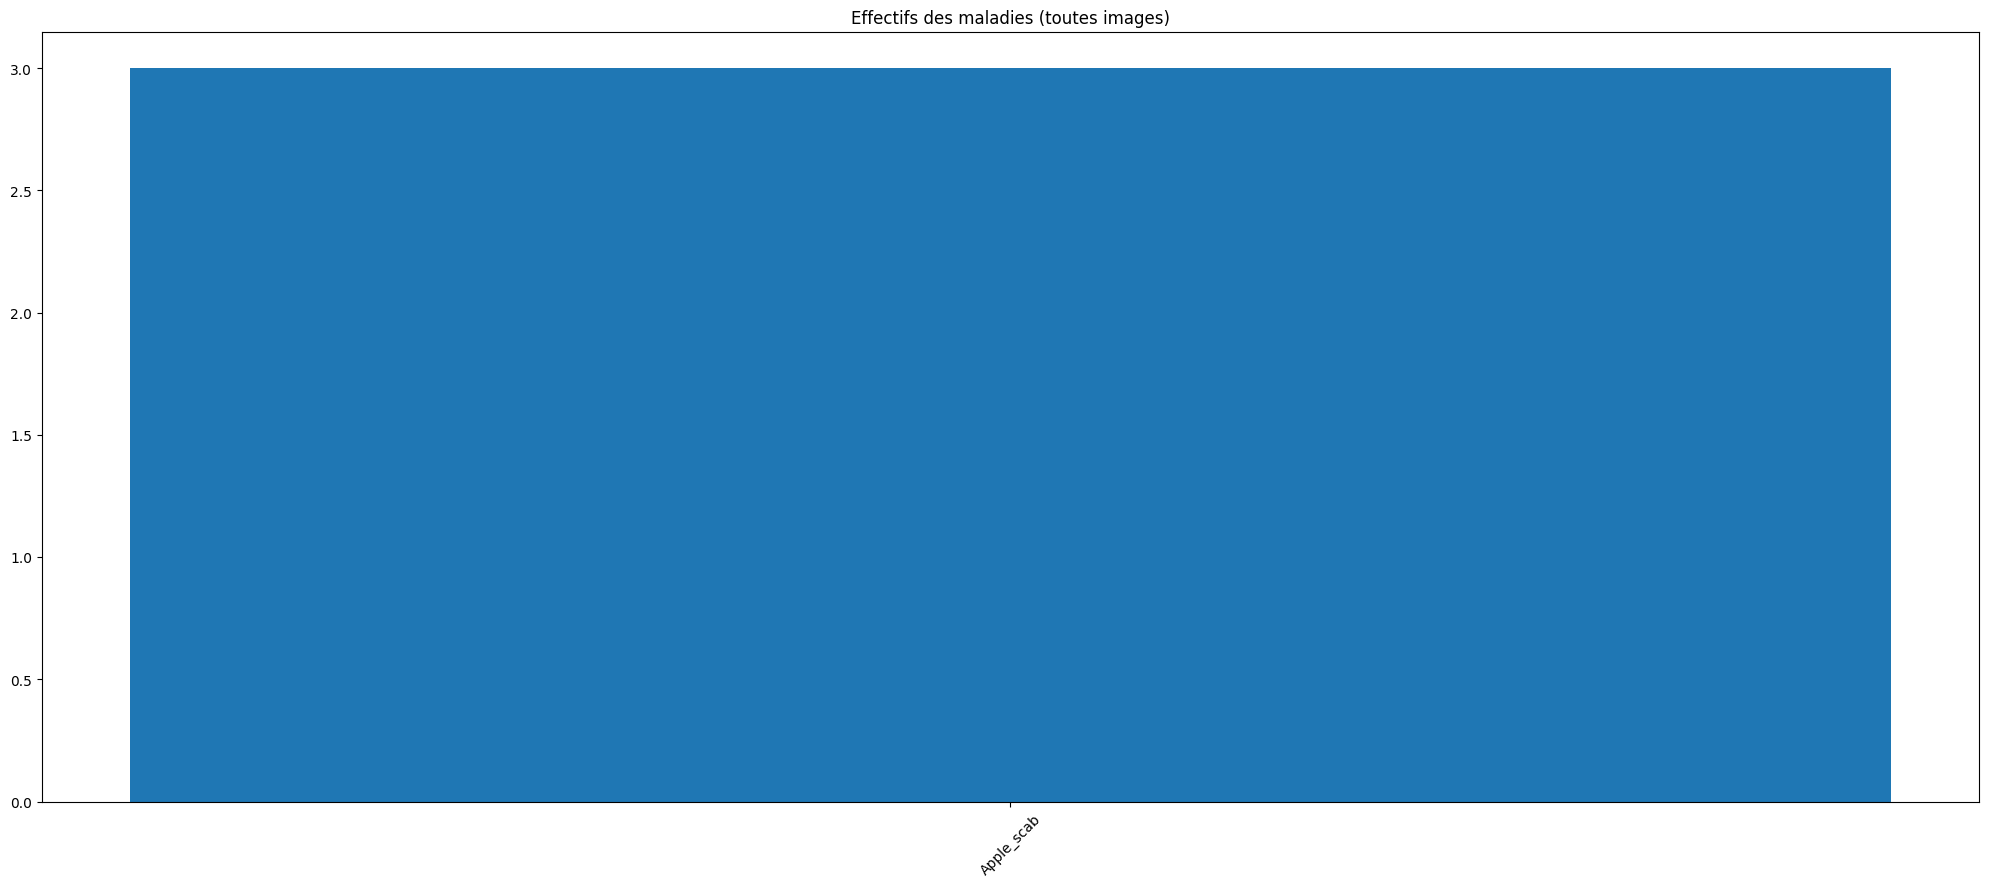

In [14]:
# ===== CELL 6 : Histogramme des maladies =====

display_diseases_histo()

In [15]:
# ===== CELL 7 : Stats catégories d'images =====

display_cat_images()

Nombre d'images:  8
Nombre de categories d'images:  7
Nombre moyen d'images par categorie:  1.0
Nombre maximum d'images dans une categorie:  1
Nombre minimum d'images dans une categorie:  1


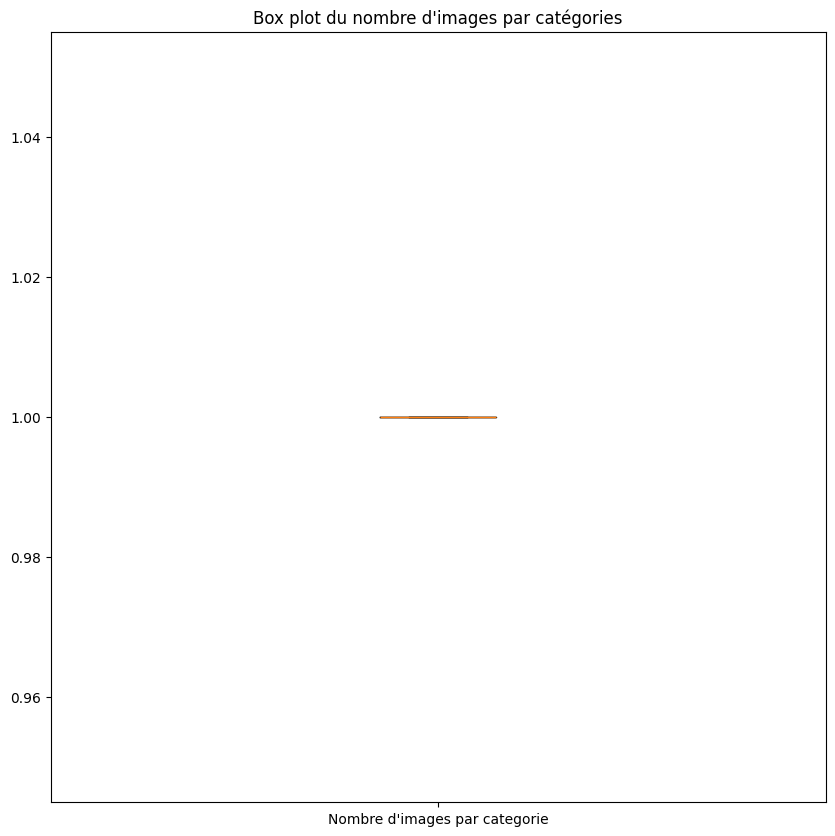

In [16]:
# ===== CELL 8 : Boxplot catégories =====

display_images_cat_box()

In [17]:
# ===== CELL 9 : Stats tailles des images =====

display_size_images()

Taille moyenne des images (Meg):  0.012
Taille mediane des images:  0.01
Taille maximum des images:  0.019
Taille minimum des images:  0.009


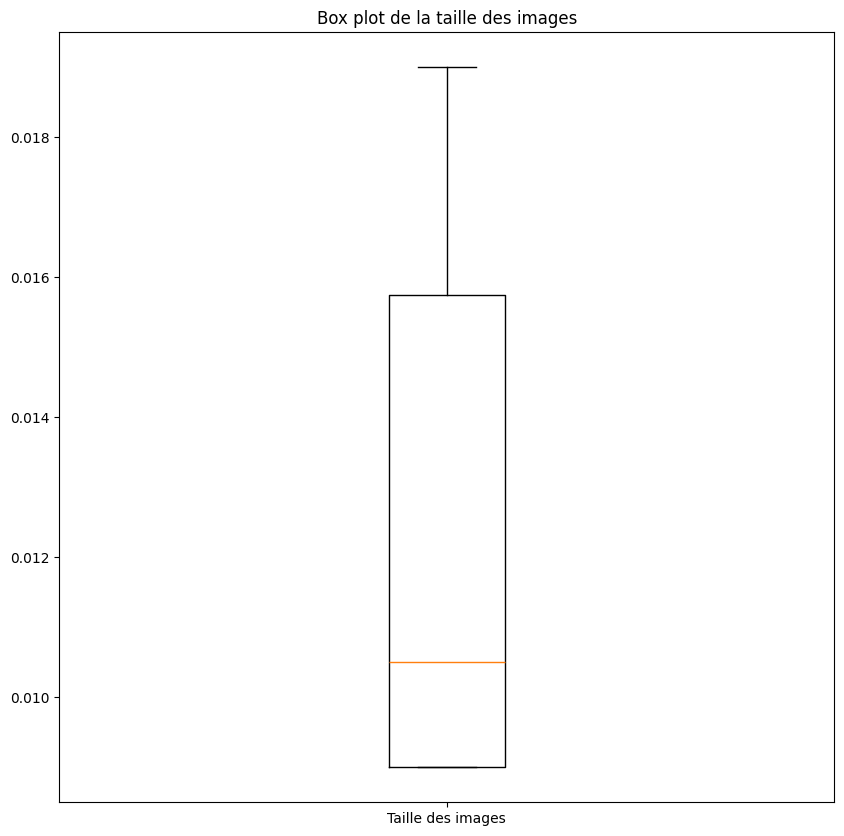

In [18]:
# ===== CELL 10 : Boxplot tailles =====

display_size_images_cat_box()

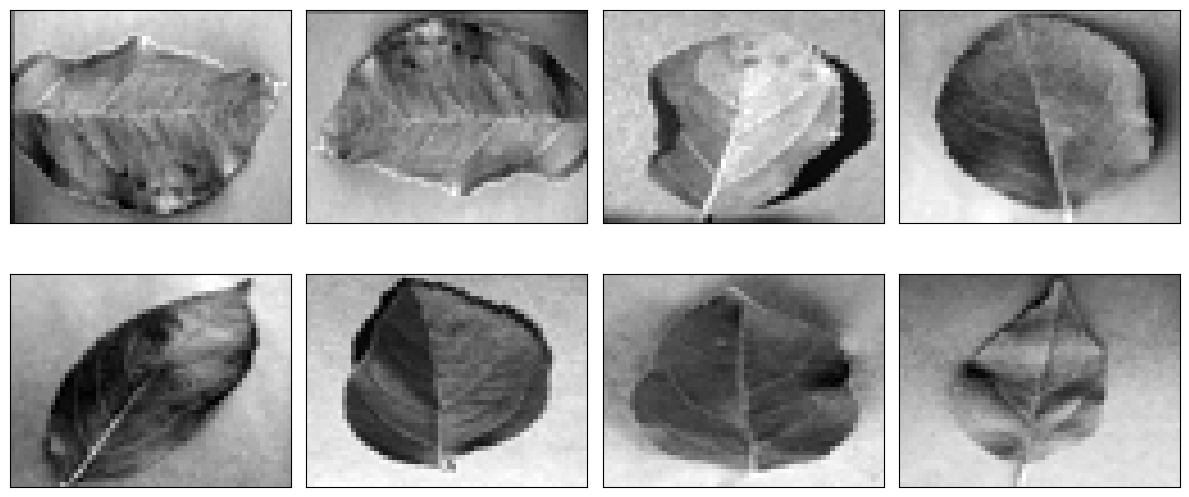

In [19]:
# ===== CELL 11 : Échantillons visuels =====

display_some_images_from_dataframe()

---
### CELL 12 : Définitions des fonctions

In [3]:
# ===== CELL 13 : Colonnes dérivées + Import des fonctions de visualisation =====

# Création des colonnes dérivées manquantes

# cat_num_image : groupe les variantes d'une même image (augmentations : _90deg, _270deg, _new30degFlipLR)
df['cat_num_image'] = df['filename'].str.replace(r'(_90deg|_270deg|_new30degFlipLR)\.JPG$', '', regex=True)

# file_size_meg : calcule la taille des fichiers depuis le filepath
df['file_size_meg'] = df['filepath'].apply(lambda p: round(os.stat(p).st_size / (1024 * 1024), 3))

# Lier le DataFrame au module de visualisation
import plants_viz
plants_viz.df = df

# Importer les fonctions dans le namespace du notebook
from plants_viz import *